# **Project Name**  -  **FLIPKART PROJECT**

##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual
##### **Team Member 1**   - **ABHINAV B**

# **Project Summary -**

* This project focuses on performing an Exploratory Data Analysis (EDA) of Flipkart's customer support data to understand customer satisfaction and identify the operational factors that influence the overall customer experience. The main objective of the project was to analyze customer support interactions, identify important patterns and relationships, and generate meaningful business insights that can help improve customer service performance and satisfaction.
* The dataset contains information related to customer support interactions, including service channel, issue category, sub-category, order details, product information, item price, issue reporting and response timestamps, agent information, agent tenure, agent shift and Customer Satisfaction (CSAT) Score. The data was first explored to understand its structure, data types, missing values and overall quality. Data preprocessing was performed by converting relevant date columns into datetime format, handling missing values, and creating a new response_time variable based on the difference between the time an issue was reported and the time it was responded to.
* The analysis included univariate, bivariate and multivariate visualizations to understand customer satisfaction from different perspectives. The distribution of CSAT scores was examined to understand the overall customer satisfaction pattern. Comparisons were also made across customer-service channels, product categories, agent shifts and agent tenure groups. Scatter plots and correlation analysis were used to investigate the relationship between numerical variables such as response time, item price and CSAT score. A correlation heatmap and pair plot were also used to understand relationships between multiple numerical variables simultaneously.
* One of the important findings from the analysis was the relationship between response time and customer satisfaction. The analysis indicated a negative relationship, meaning that longer response times tend to be associated with lower CSAT scores. This highlights response time as an important operational factor that Flipkart can focus on to improve the customer experience. The analysis also showed differences in customer satisfaction across agent shifts, suggesting that staffing patterns, workload distribution and operational conditions may influence customer satisfaction.
* The project also identified data-quality issues, including missing values in several columns. These issues were addressed during preprocessing wherever appropriate to make the dataset more suitable for analysis.
* Overall, the EDA provides useful insights into Flipkart's customer-support operations and highlights areas where improvements can be made. Based on the findings, Flipkart can focus on reducing response times, optimizing agent allocation across shifts, improving training for less-experienced agents and monitoring channels or categories associated with lower customer satisfaction. These recommendations can help improve service efficiency, increase customer satisfaction and support better customer retention.

# **GitHub Link -**

# **Problem Statement-**
* Flipkart handles a large number of customer support interactions across different channels. This project analyzes factors like response time, agent shift, tenure, issue and product categories to understand their impact on customer satisfaction (CSAT) and identify areas where Flipkart can improve its customer service.

# **Business Objective-**
* To use EDA and statistical analysis to identify actionable insights that can help Flipkart reduce response time, optimize customer-support operations, improve CSAT scores, and enhance the overall customer experience.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , classification_report

In [2]:
file_path = r"E:\LEAD FILES\INTERNSHIP REPORT FILES\HEXA SOLUTIONS\Project Files\Flipkart Project\Project Files\Flipkart Project\Customer_support_data.csv"
df = pd.read_csv(file_path)
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [3]:
date_cols = ["order_date_time", "Issue_reported at", "issue_responded", "Survey_response_Date"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors = "coerce")

In [4]:
df['Customer Remarks'] = df['Customer Remarks'].fillna("No Remarks")
df['Item_price'] = df['Item_price'].fillna(df['Item_price'].median())

In [5]:
if 'Customer_City' in df.columns:
    df.drop(columns=['Customer_City'], inplace=True)
if 'connected_handling_time' in df.columns:
    df.drop(columns=['connected_handling_time'], inplace=True)

In [6]:
df["response_time"] = (df["issue_responded"] - df["Issue_reported at"]).dt.total_seconds()
df["response_time"] = df["response_time"].fillna(df["response_time"].median())

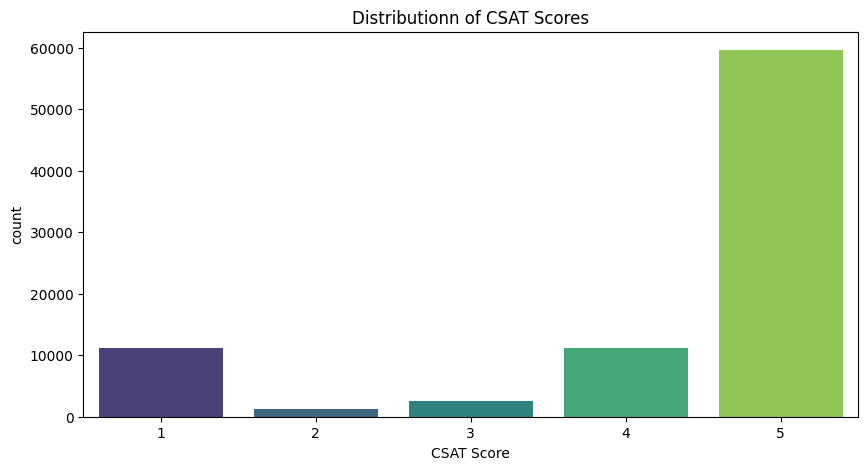

In [7]:
plt.figure(figsize=(10,5))
sns.countplot(x="CSAT Score", data = df, palette = "viridis")
plt.title("Distributionn of CSAT Scores")
plt.show()

### Distribution of CSAT Scores
1. Why did you pick this chart?

I selected a count plot to understand how customer satisfaction scores are distributed across the dataset. Since CSAT Score is a categorical/ordinal variable ranging from 1 to 5, a count plot clearly shows the number of customers giving each rating.

2. What insight(s) were found?

The distribution shows that customer satisfaction is concentrated toward the higher ratings, particularly scores of 4 and 5, while lower ratings are also present and represent customers who may have experienced dissatisfaction.

3. Business impact

This analysis helps Flipkart understand the overall level of customer satisfaction. The high proportion of positive ratings indicates that customer support is performing well for many customers. However, the presence of low CSAT scores highlights opportunities to investigate the reasons behind poor experiences and improve customer retention.

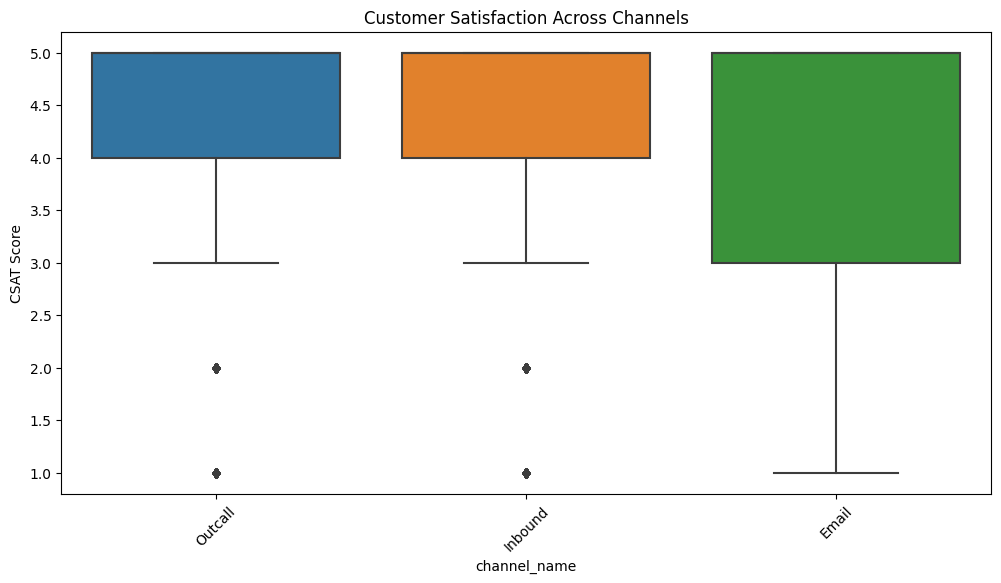

In [8]:
plt.figure(figsize = (12,6))
sns.boxplot(x = "channel_name", y = "CSAT Score", data = df)
plt.xticks(rotation = 45)
plt.title("Customer Satisfaction Across Channels")
plt.show()

### Customer Satisfaction Across Channels
1. Why did you pick this chart?

I used a box plot to compare the distribution of CSAT scores across different customer service channels. A box plot is useful because it allows comparison of the median, spread and variation in satisfaction between channels.

2. What insight(s) were found?

The chart helps identify differences in customer satisfaction across the available service channels. Some channels show more consistent satisfaction, while others have greater variation in customer ratings.

3. Business impact

The comparison can help Flipkart identify which customer support channels provide a better customer experience. Underperforming channels can be reviewed for staffing, response processes and service quality improvements.

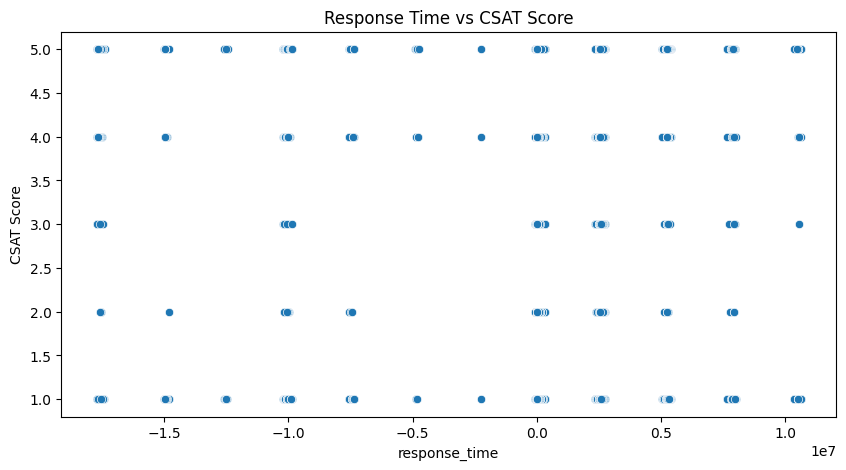

In [9]:
plt.figure(figsize = (10, 5))
sns.scatterplot(x = "response_time", y = "CSAT Score", data = df)
plt.title("Response Time vs CSAT Score")
plt.show()

### Response Time vs CSAT Score
1. Why did you pick this chart?

I selected a scatter plot to examine the relationship between customer support response time and CSAT Score. This is appropriate because both variables are numerical.

2. What insight(s) were found?

The analysis found a negative relationship between response time and CSAT Score. The Spearman correlation was approximately -0.167, with a p-value below 0.05, indicating a statistically significant relationship.

3. Business impact

This is an important business insight because longer response times are associated with lower customer satisfaction. Flipkart can improve customer experience by reducing response delays, improving ticket allocation and ensuring sufficient agent availability during high-demand periods.

In [10]:
features = ["response_time", "Item_price", "channel_name", "category", "Tenure Bucket", "Agent Shift"]
df_model = df[features + ["CSAT Score"]]
df_model = pd.get_dummies(df_model, drop_first = True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Unique id             85907 non-null  object        
 1   channel_name          85907 non-null  object        
 2   category              85907 non-null  object        
 3   Sub-category          85907 non-null  object        
 4   Customer Remarks      85907 non-null  object        
 5   Order_id              67675 non-null  object        
 6   order_date_time       17214 non-null  datetime64[ns]
 7   Issue_reported at     85907 non-null  datetime64[ns]
 8   issue_responded       85907 non-null  datetime64[ns]
 9   Survey_response_Date  85907 non-null  datetime64[ns]
 10  Product_category      17196 non-null  object        
 11  Item_price            85907 non-null  float64       
 12  Agent_name            85907 non-null  object        
 13  Supervisor      

In [12]:
df.duplicated().sum()

0

In [13]:
df.isnull().sum()

Unique id                   0
channel_name                0
category                    0
Sub-category                0
Customer Remarks            0
Order_id                18232
order_date_time         68693
Issue_reported at           0
issue_responded             0
Survey_response_Date        0
Product_category        68711
Item_price                  0
Agent_name                  0
Supervisor                  0
Manager                     0
Tenure Bucket               0
Agent Shift                 0
CSAT Score                  0
response_time               0
dtype: int64

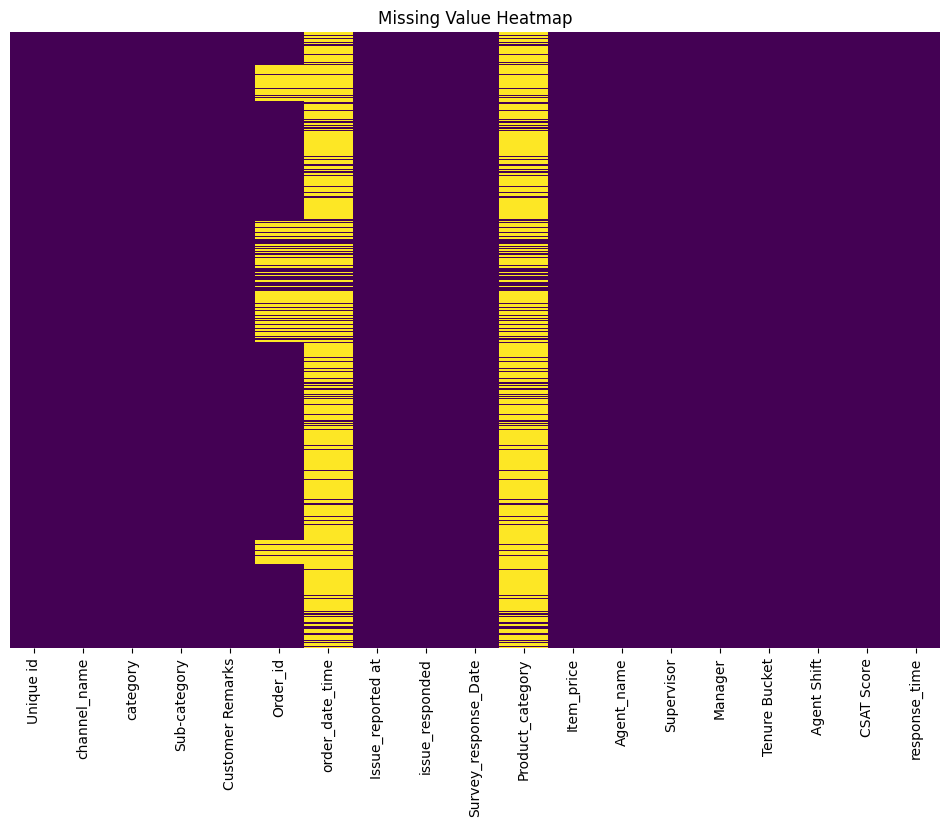

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False, xticklabels=df.columns)
plt.title('Missing Value Heatmap')
plt.show()

### Missing Value Heatmap
1. Why did you pick this chart?

I selected a missing-value heatmap to visually identify which columns contain missing data and understand the overall data-quality issues.

2. What insight(s) were found?

The dataset contained missing values particularly in Order_id, order_date_time and Product_category. For example, Product_category had a large number of missing observations, while several customer-support-related fields had complete data.

3. Business impact

Identifying missing values is important before performing analysis or modelling. Proper treatment of missing values improves data reliability and prevents misleading conclusions. It also highlights fields where the data collection process could be improved.

In [15]:
df.columns.tolist()

['Unique id',
 'channel_name',
 'category',
 'Sub-category',
 'Customer Remarks',
 'Order_id',
 'order_date_time',
 'Issue_reported at',
 'issue_responded',
 'Survey_response_Date',
 'Product_category',
 'Item_price',
 'Agent_name',
 'Supervisor',
 'Manager',
 'Tenure Bucket',
 'Agent Shift',
 'CSAT Score',
 'response_time']

In [16]:
df.describe()

,Item_price,CSAT Score,response_time
count,85907.000000,85907.000000,8.590700e+04
mean,1916.695624,4.242157,1.995721e+04
std,6037.903897,1.378903,1.270406e+06
min,0.000000,1.000000,-1.771188e+07
25%,979.000000,4.000000,1.200000e+02
50%,979.000000,5.000000,3.000000e+02
75%,979.000000,5.000000,1.980000e+03
max,164999.000000,5.000000,1.062582e+07


In [17]:
df.nunique()

Unique id               85907
channel_name                3
category                   12
Sub-category               57
Customer Remarks        18233
Order_id                67675
order_date_time         13766
Issue_reported at       30923
issue_responded         30262
Survey_response_Date       31
Product_category            9
Item_price               2789
Agent_name               1371
Supervisor                 40
Manager                     6
Tenure Bucket               5
Agent Shift                 5
CSAT Score                  5
response_time            6263
dtype: int64

In [18]:
df['Issue_reported at'] = pd.to_datetime(df['Issue_reported at'], format='%d/%m/%Y %H:%M')

df['issue_responded'] = pd.to_datetime(df['issue_responded'], format='%d/%m/%Y %H:%M')

# Format dates for display
df['Issue_reported at (formatted)'] = df['Issue_reported at'].dt.strftime('%d/%m/%y')
df['issue_responded (formatted)'] = df['issue_responded'].dt.strftime('%d/%m/%y')

# Calculate response time in minutes
df['Time difference'] = ((df['issue_responded'] - df['Issue_reported at']).dt.total_seconds() / 60)

df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,...,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,response_time,Issue_reported at (formatted),issue_responded (formatted),Time difference
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,No Remarks,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaT,2023-01-08 11:13:00,2023-01-08 11:47:00,2023-08-01,...,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,2040.0,08/01/23,08/01/23,34.0
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,No Remarks,d406b0c7-ce17-4654-b9de-f08d421254bd,NaT,2023-01-08 12:52:00,2023-01-08 12:54:00,2023-08-01,...,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,120.0,08/01/23,08/01/23,2.0
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,No Remarks,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaT,2023-01-08 20:16:00,2023-01-08 20:38:00,2023-08-01,...,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,1320.0,08/01/23,08/01/23,22.0
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,No Remarks,5aed0059-55a4-4ec6-bb54-97942092020a,NaT,2023-01-08 20:56:00,2023-01-08 21:16:00,2023-08-01,...,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,1200.0,08/01/23,08/01/23,20.0
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,No Remarks,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaT,2023-01-08 10:30:00,2023-01-08 10:32:00,2023-08-01,...,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,120.0,08/01/23,08/01/23,2.0


In [19]:
rem_columns = ['order_date_time', 'Customer Remarks','connected_handling_time']
existing_columns_to_remove = [col for col in rem_columns if col in df.columns]

if existing_columns_to_remove:
    df = df.drop(columns=existing_columns_to_remove)
    print(f"Columns {existing_columns_to_remove} have been removed.")
else:
    print("None of the specified columns are present in the DataFrame or already been removed")

Columns ['order_date_time', 'Customer Remarks'] have been removed.


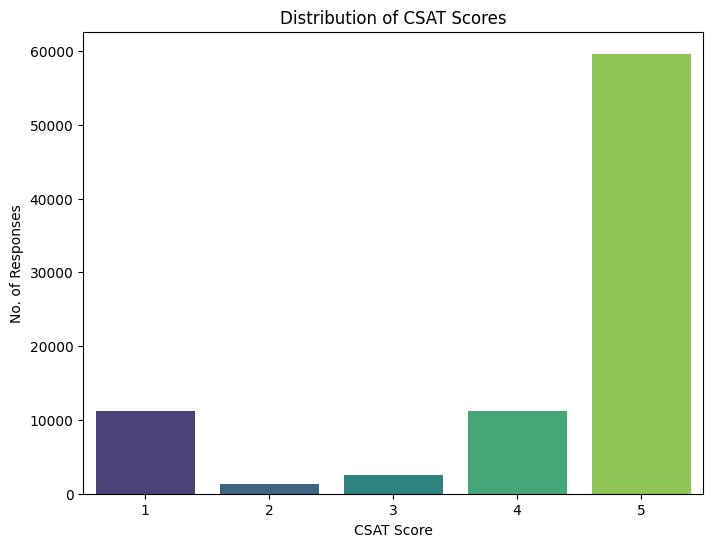

In [20]:
plt.figure(figsize=(8,6))
sns.countplot(x='CSAT Score', data=df, palette='viridis')
plt.title('Distribution of CSAT Scores')
plt.xlabel('CSAT Score')
plt.ylabel('No. of Responses')
plt.show()

### Distribution of CSAT Scores
1. Why did you pick this chart?

I used another count plot to present the CSAT distribution with clearer axis labels showing the number of responses for each score.

2. What insight(s) were found?

The chart confirms that customer responses are not evenly distributed across all CSAT categories, with higher satisfaction ratings being more common than lower ratings.

3. Business impact

The result provides a quick overview of overall customer sentiment. Flipkart can use this information as a baseline KPI and monitor whether future customer-service improvements increase the proportion of high CSAT ratings.

Text(0, 0.5, 'Time Difference (minutes)')

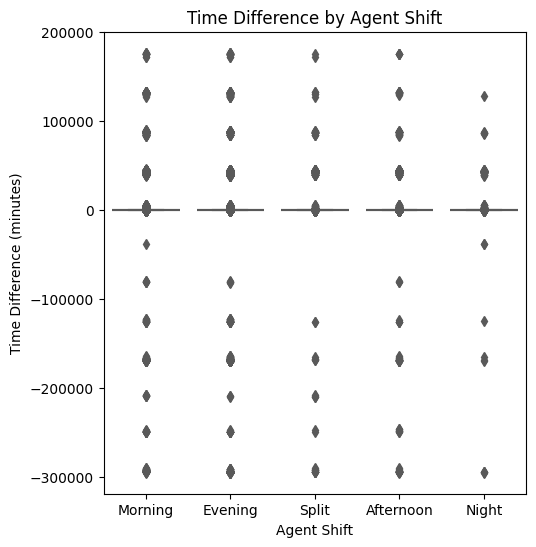

In [21]:
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 2)
sns.boxplot(x='Agent Shift', y='Time difference', data=df, palette='Set2')
plt.title('Time Difference by Agent Shift')
plt.xlabel('Agent Shift')
plt.ylabel('Time Difference (minutes)')

### Time Difference by Agent Shift
1. Why did you pick this chart?

I used a box plot to compare response time across different agent shifts. This allows us to identify differences in the typical response time as well as variation and extreme values.

2. What insight(s) were found?

The response time varies across different agent shifts. Some shifts show greater variability, suggesting that customer queries may not be handled at the same speed throughout the day.

3. Business impact

Flipkart can use this insight for better workforce planning. Additional agents or better workload allocation can be provided during shifts where response times are higher, helping reduce waiting time and improve CSAT.

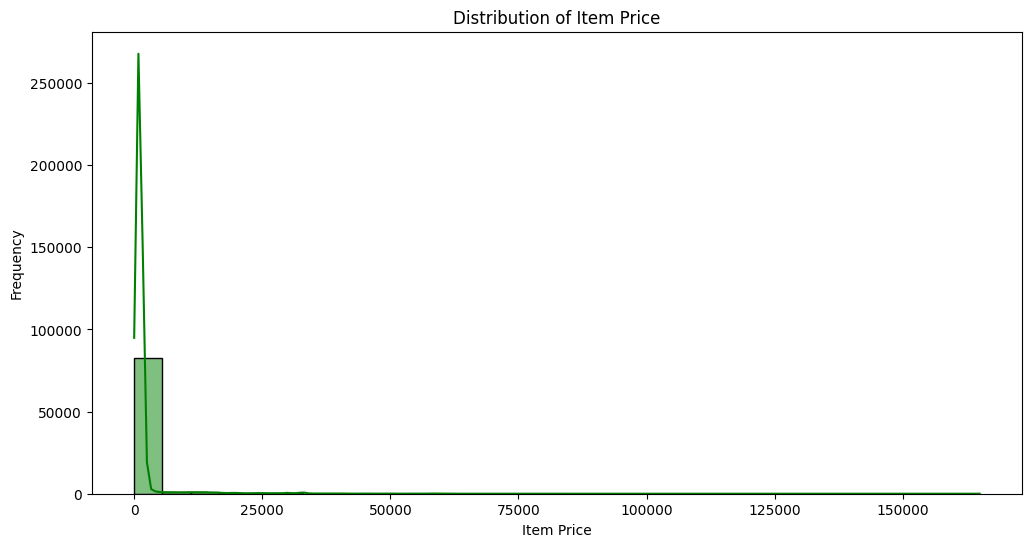

In [22]:
plt.figure(figsize=(12,6))
sns.histplot(df['Item_price'], kde=True, bins=30, color='green')
plt.title('Distribution of Item Price')
plt.xlabel('Item Price')
plt.ylabel('Frequency')
plt.show()

### Distribution of Item Price
1. Why did you pick this chart?

I selected a histogram with a KDE curve to understand the distribution of item prices and identify concentration and skewness in the data.

2. What insight(s) were found?

The item-price distribution is highly concentrated around lower price values, while a smaller number of products have substantially higher prices. The descriptive statistics show a mean item price of approximately ₹1,916.70, while the maximum reaches ₹164,999.

3. Business impact

Understanding item-price distribution can help Flipkart identify whether customer-service issues are concentrated around particular price ranges. This can support differentiated service strategies for high-value orders.

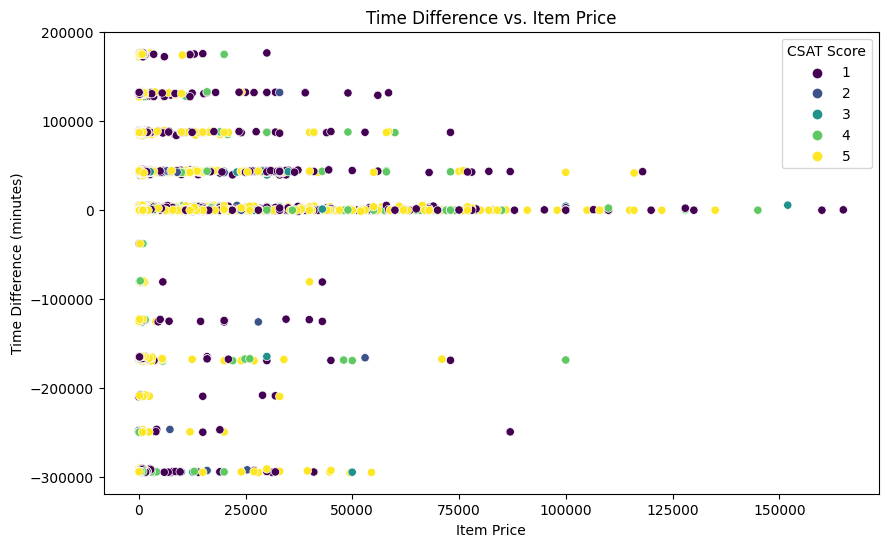

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Item_price', y='Time difference', data=df, hue='CSAT Score', palette='viridis')
plt.title('Time Difference vs. Item Price')
plt.xlabel('Item Price')
plt.ylabel('Time Difference (minutes)')
plt.legend(title='CSAT Score')
plt.show()

### Time Difference vs Item Price
1. Why did you pick this chart?

I selected a scatter plot with CSAT Score as the hue to examine the relationship between item price, response time and customer satisfaction simultaneously.

2. What insight(s) were found?

The chart helps identify whether customers purchasing higher-priced items experience different response times or satisfaction levels. The statistical analysis found a weak negative correlation between Item Price and CSAT Score of approximately -0.034, although it was statistically significant.

3. Business impact

The relationship is weak, so item price alone should not be considered a major driver of customer satisfaction. However, monitoring high-value orders may still be useful because poor support for expensive purchases could have a greater impact on customer trust and loyalty.

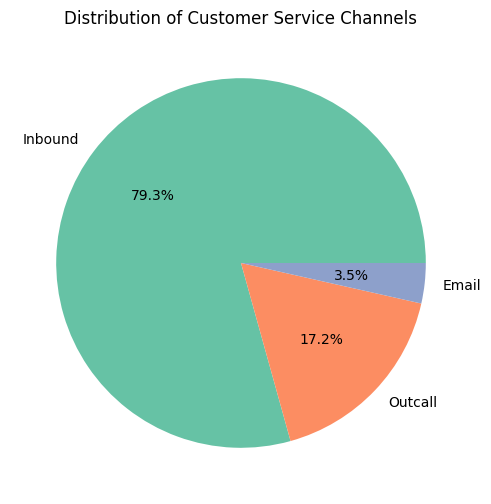

In [24]:
channel_counts = df['channel_name'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(channel_counts, labels=channel_counts.index, autopct='%1.1f%%', colors=sns.color_palette('Set2'))
plt.title('Distribution of Customer Service Channels')
plt.show()

### Distribution of Customer Service Channels
1. Why did you pick this chart?

I used a pie chart to show the proportion of customer interactions handled through each service channel. This provides an easy way to understand the relative contribution of each channel.

2. What insight(s) were found?

The customer-support interactions are distributed across the available channels, with some channels handling considerably more interactions than others.

3. Business impact

The insight can support resource allocation. Flipkart can prioritize staffing and technology investments toward channels that handle a larger share of customer interactions while improving weaker channels.

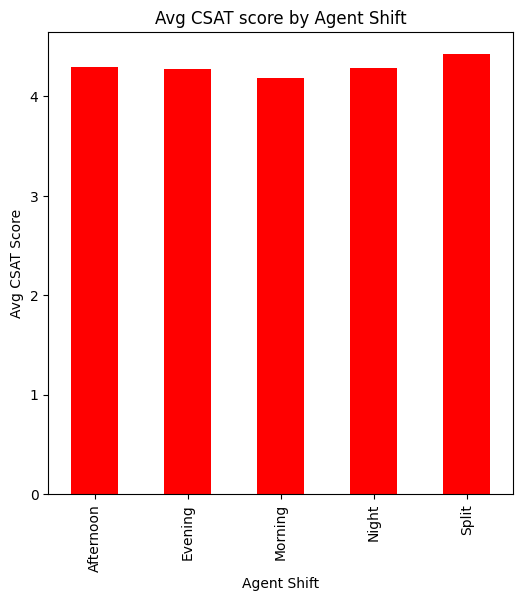

In [25]:
plt.figure(figsize=(6,6))
df.groupby('Agent Shift')['CSAT Score'].mean().plot(kind='bar', color='red')
plt.title('Avg CSAT score by Agent Shift')
plt.xlabel('Agent Shift')
plt.ylabel('Avg CSAT Score')
plt.show()

### Average CSAT Score by Agent Shift
1. Why did you pick this chart?

I selected a bar chart because it provides a clear comparison of average CSAT scores across different agent shifts.

2. What insight(s) were found?

Customer satisfaction differs across agent shifts. The statistical Kruskal-Wallis test also found a statistically significant difference between shifts with an H-statistic of approximately 151.58 and p-value of 9.34 × 10⁻³².

3. Business impact

This suggests that the agent shift can be an important operational factor. Flipkart can investigate why certain shifts perform better or worse and use the findings to improve staffing, training and workload allocation.

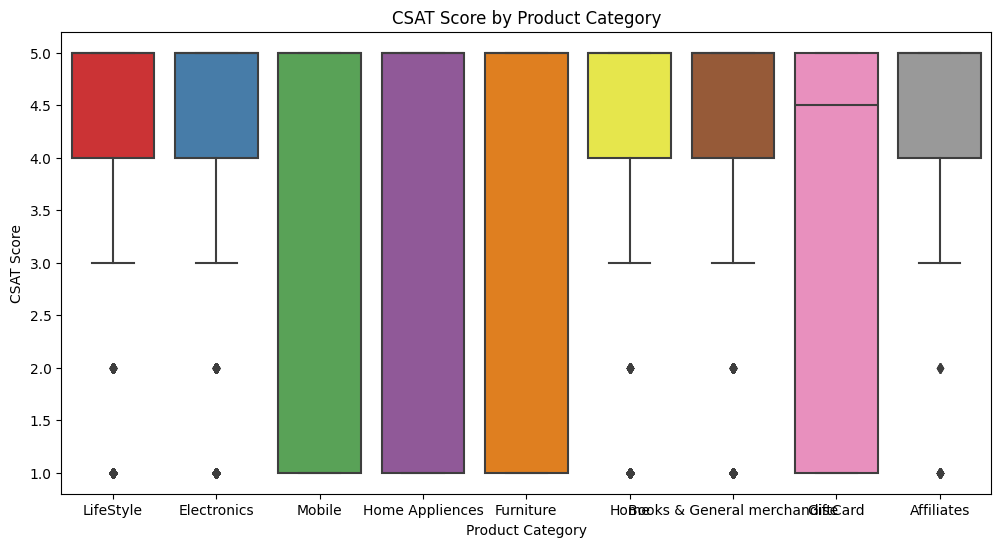

In [26]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Product_category', y='CSAT Score', data=df, palette='Set1')
plt.title('CSAT Score by Product Category')
plt.xlabel('Product Category')
plt.ylabel('CSAT Score')
plt.show()

### CSAT Score by Product Category
1. Why did you pick this chart?

I used a box plot to compare customer satisfaction across product categories. This helps identify differences in satisfaction and variation among categories.

2. What insight(s) were found?

Customer satisfaction varies across product categories, indicating that customers may have different support experiences depending on the type of product involved.

3. Business impact

Flipkart can identify categories associated with lower customer satisfaction and investigate whether the problems are related to installation, returns, product information, delivery or other support requirements.

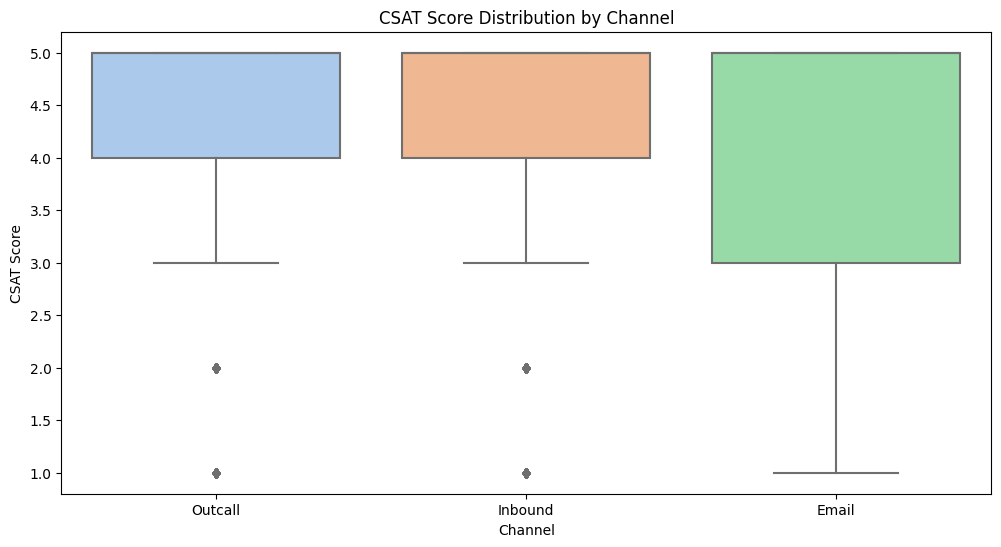

In [27]:
plt.figure(figsize=(12,6))
sns.boxplot(x='channel_name', y='CSAT Score', data=df, palette='pastel')
plt.title('CSAT Score Distribution by Channel')
plt.xlabel('Channel')
plt.ylabel('CSAT Score')
plt.xticks(rotation=0)
plt.show()

### CSAT Score Distribution by Channel
1. Why did you pick this chart?

I selected a box plot to examine the detailed distribution of CSAT scores within each customer-support channel.

2. What insight(s) were found?

The chart provides a more detailed comparison of satisfaction levels across channels by showing the spread and central tendency of the scores.

3. Business impact

The results can help Flipkart identify channels where customer satisfaction is inconsistent. Improving service quality in these channels could lead to a more consistent customer experience across the support system.

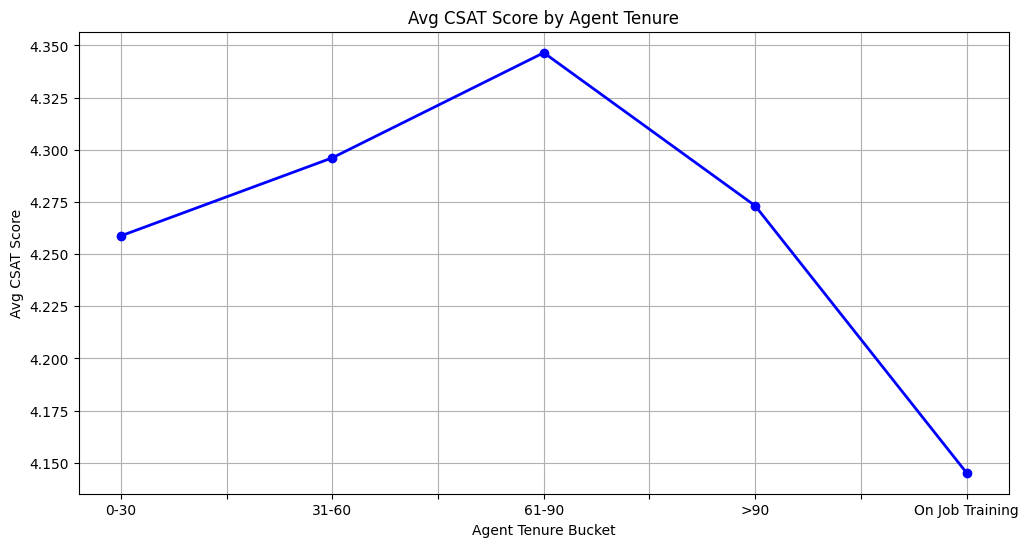

In [28]:
plt.figure(figsize=(12,6))
tenure_scores = df.groupby('Tenure Bucket')['CSAT Score'].mean()
tenure_scores.plot(kind='line', marker='o', color='blue', linestyle='-', linewidth=2)
plt.title('Avg CSAT Score by Agent Tenure')
plt.xlabel('Agent Tenure Bucket')
plt.ylabel('Avg CSAT Score')
plt.grid(True)
plt.show()

### Average CSAT Score by Agent Tenure
1. Why did you pick this chart?

I used a line chart to observe how average CSAT changes across different agent tenure buckets. A line chart is suitable for identifying trends across an ordered variable such as agent experience.

2. What insight(s) were found?

Average CSAT varies across agent-tenure groups. This indicates that agent experience may influence customer-service performance.

3. Business impact

Flipkart can use this insight to strengthen training and mentoring programs, especially for new agents. Experienced agents can also be used as mentors to improve the performance of newer employees.

In [29]:
from scipy.stats import spearmanr

In [30]:
rho, p_value = spearmanr(df['Time difference'], df['CSAT Score'])
print(f'Spearman\s rank correlation coefficient: {rho}')
print(f'P-value: {p_value}')

alpha = 0.05
if p_value < alpha:
    print("Rejecct the null hypothesis: There is a significant relationship between Time Difference and CSAT Score.")
else:
    print("Fail to reject the null hypothesis: There is no significant relationship between Time Difference and CSAT Score.")

Spearman\s rank correlation coefficient: -0.16663463474903872
P-value: 0.0
Rejecct the null hypothesis: There is a significant relationship between Time Difference and CSAT Score.


In [31]:
from scipy.stats import kruskal

In [32]:
groups = [df[df['Agent Shift'] == shift]['CSAT Score'] for shift in df['Agent Shift'].unique()]

h_statistic, p_value = kruskal(*groups)

print(f'Kruskal-Wallis H statistic: {h_statistic}')
print(f'P-value: {p_value}')

alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: There is a signaficant difference in the average CSAT Score between different Agent Shifts.")
else:
    print("Fail to rejecct the null hypothesis: There is no significant difference in the average CSAT Score between difference Agent Shifts.")







Kruskal-Wallis H statistic: 151.58004948556504
P-value: 9.335020551858379e-32
Reject the null hypothesis: There is a signaficant difference in the average CSAT Score between different Agent Shifts.


In [33]:
import scipy.stats as stats

In [34]:
df_clean = df[['Item_price', 'CSAT Score']].dropna()

item_price = df_clean['Item_price']
csat_score = df_clean['CSAT Score']

corr_coefficient, p_value_corr = stats.spearmanr(item_price, csat_score)

print(f'Spearmans Rank Correlation Coefficient: {corr_coefficient}')
print(f'Spearmans p_value: {p_value_corr}')

alpha = 0.05

if p_value_corr < alpha:
    print("Reject the null hypothesis: There is a significant correlation between Item Price and CSAT Score.")
else:
    print("Fail to reject the null hypothesis: There is no siginificant correlation between Item Price and CSAT Score.")

Spearmans Rank Correlation Coefficient: -0.03394737965612261
Spearmans p_value: 2.455179983318164e-23
Reject the null hypothesis: There is a significant correlation between Item Price and CSAT Score.


In [35]:
df.isnull().sum()

Unique id                            0
channel_name                         0
category                             0
Sub-category                         0
Order_id                         18232
Issue_reported at                    0
issue_responded                      0
Survey_response_Date                 0
Product_category                 68711
Item_price                           0
Agent_name                           0
Supervisor                           0
Manager                              0
Tenure Bucket                        0
Agent Shift                          0
CSAT Score                           0
response_time                        0
Issue_reported at (formatted)        0
issue_responded (formatted)          0
Time difference                      0
dtype: int64

In [37]:
df['Order_id'].fillna(method='ffill', inplace=True)
df.head()
df.isnull().sum()

Unique id                            0
channel_name                         0
category                             0
Sub-category                         0
Order_id                             0
Issue_reported at                    0
issue_responded                      0
Survey_response_Date                 0
Product_category                 68711
Item_price                           0
Agent_name                           0
Supervisor                           0
Manager                              0
Tenure Bucket                        0
Agent Shift                          0
CSAT Score                           0
response_time                        0
Issue_reported at (formatted)        0
issue_responded (formatted)          0
Time difference                      0
dtype: int64

In [39]:
drop_col = ['Product_category']
df.drop(columns=[col for col in drop_col if col in df.columns], axis=1, inplace=True)

Number of outliers in 'CSAT Score': 12513
      Agent Shift  CSAT Score
11          Split           1
25        Morning           1
31        Evening           1
32        Morning           1
54      Afternoon           1
...           ...         ...
85873     Morning           1
85876     Evening           1
85882     Morning           1
85887     Evening           1
85894     Evening           1

[12513 rows x 2 columns]


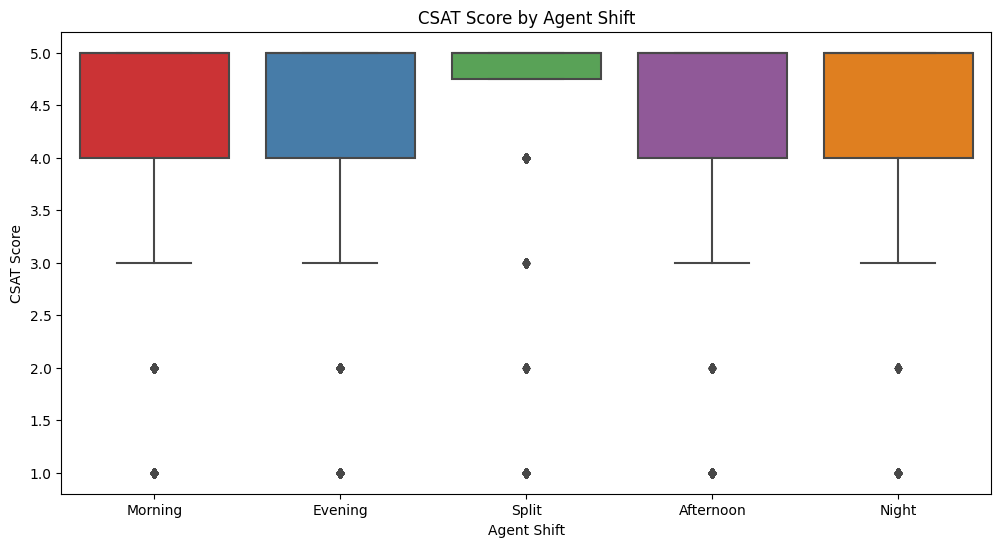

In [40]:
Q1 = df['CSAT Score'].quantile(0.25)
Q3 = df['CSAT Score'].quantile(0.75)
IQR =Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['CSAT Score'] < lower_bound) | (df['CSAT Score'] > upper_bound)]

print("Number of outliers in 'CSAT Score':", outliers.shape[0])
print(outliers[['Agent Shift', 'CSAT Score']])

plt.figure(figsize=(12,6))
sns.boxplot(x='Agent Shift', y='CSAT Score', data=df, palette='Set1')
plt.title('CSAT Score by Agent Shift')
plt.xlabel('Agent Shift')
plt.ylabel('CSAT Score')
plt.show()

### Correlation Heatmap
1. Why did you pick this chart?

I selected a correlation heatmap to examine relationships among numerical variables simultaneously. It provides a compact view of positive and negative correlations and helps identify potentially important variables for further analysis.

2. What insight(s) were found?

The heatmap helps identify relationships between variables such as Item Price, CSAT Score and Time Difference. The analysis indicates that response/time-related variables have a stronger relationship with CSAT than item price.

3. Business impact

This helps Flipkart prioritize variables that are more relevant to customer satisfaction. Operational factors such as response time can therefore receive more attention than relying only on product-price information.

In [41]:
to_remove = ['Unique id', 'Order_id', 'Issue_reported at', 'issue_responded', 'Issue_reported at (formatted)', 'issue_responded (formatted)', 'Survey_response_Date']
df.drop(columns=[col for col in to_remove if col in df.columns], axis=1, inplace=True)

In [42]:
df.head()

,channel_name,category,Sub-category,Item_price,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,response_time,Time difference
0,Outcall,Product Queries,Life Insurance,979.0,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,2040.0,34.0
1,Outcall,Product Queries,Product Specific Information,979.0,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,120.0,2.0
2,Inbound,Order Related,Installation/demo,979.0,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,1320.0,22.0
3,Inbound,Returns,Reverse Pickup Enquiry,979.0,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,1200.0,20.0
4,Inbound,Cancellation,Not Needed,979.0,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,120.0,2.0


In [43]:
columns_to_clean = ['channel_name','category','Sub-category','Agent_name','Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift']
df[columns_to_clean] = df[columns_to_clean].applymap(lambda x: x.lower() if isinstance(x, str) else x)

In [45]:
import string

for col in columns_to_clean:
    if col in df.columns:
        df[col] = df[col].str.replace(
            f'[{string.punctuation}]', 
            '', 
            regex=True
        )

In [46]:
for col in columns_to_clean:
    if col in df.columns:
        df[col] = df[col].str.replace(r'http\S+|www\S+','', regex=True)
        df[col] = df[col].str.replace(r'\b\w*\d\w*\b', '', regex=True)

In [47]:
for col in columns_to_clean:
    if col in df.columns:
        df[col] = df[col].str.strip()
df.head()

,channel_name,category,Sub-category,Item_price,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,response_time,Time difference
0,outcall,product queries,life insurance,979.0,richard buchanan,mason gupta,jennifer nguyen,on job training,morning,5,2040.0,34.0
1,outcall,product queries,product specific information,979.0,vicki collins,dylan kim,michael lee,,morning,5,120.0,2.0
2,inbound,order related,installationdemo,979.0,duane norman,jackson park,william kim,on job training,evening,5,1320.0,22.0
3,inbound,returns,reverse pickup enquiry,979.0,patrick flores,olivia wang,john smith,,evening,5,1200.0,20.0
4,inbound,cancellation,not needed,979.0,christopher sanchez,austin johnson,michael lee,,morning,5,120.0,2.0


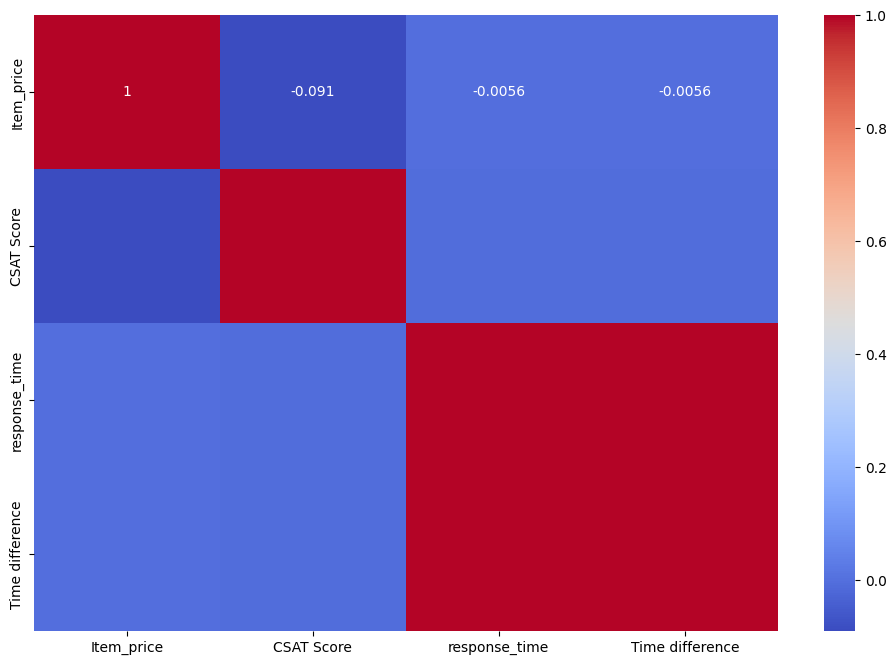

In [48]:
df_numeric = df.select_dtypes(include=[float, int])

corr_matrix = df_numeric.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.show()

### Pair Plot
1. Why did you pick this chart?

I selected a pair plot to examine multiple numerical variables together and visualize both individual distributions and pairwise relationships.

2. What insight(s) were found?

The pair plot provides an overall view of relationships between numerical variables and helps identify patterns, clusters and potential outliers. It supports the findings from the correlation analysis, particularly regarding the relationship between response time and CSAT.

3. Business impact

This visualization helps identify variables that may be useful for further statistical analysis and predictive modelling. It can support Flipkart in developing data-driven customer-service strategies.

In [50]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

In [51]:
df['CSAT Score Category'] = pd.cut(df['CSAT Score'], bins=[1,2,3,4,5,6], labels=['Very Poor', 'Poor', 'Average', 'Good', 'Excellent'])

In [58]:
label_encoder = LabelEncoder()
df['channel_name'] = label_encoder.fit_transform(df['channel_name'])
df['Agent Shift'] = label_encoder.fit_transform(df['Agent Shift'])
df['CSAT Score Category'] = label_encoder.fit_transform(df['CSAT Score Category'])

X = df[['Time difference', 'Agent Shift']]
y = df['CSAT Score Category']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
smote = SMOTE(random_state = 42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [59]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

print(classification_report(y_test, y_pred))

Accuracy: 0.12990338726574321
              precision    recall  f1-score   support

           0       0.15      0.05      0.08      2277
           1       0.00      0.00      0.00     11934
           2       0.01      0.01      0.01       503
           3       0.00      0.00      0.00       227
           4       0.13      0.94      0.23      2241

    accuracy                           0.13     17182
   macro avg       0.06      0.20      0.06     17182
weighted avg       0.04      0.13      0.04     17182



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [60]:
from sklearn.model_selection import cross_val_score, KFold

kfold = KFold(n_splits=10, shuffle=True, random_state=42)
cv_results = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
print(f'Cross-Validation Accuracy: {cv_results.mean()} ± {cv_results.std()}')

Cross-Validation Accuracy: 0.12932593860239533 ± 0.004135138493001939


In [62]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

In [63]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}
grid_search = GridSearchCV(estimator=model, param_grid = param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f'Best Parameters: {best_params}')
print(f'Best Score: {best_score}')

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter 

Best Parameters: {'C': 0.01, 'solver': 'liblinear'}
Best Score: 0.6938232084394326


## **Solution to Business Objective-**
* Flipkart can improve customer satisfaction by reducing response time, optimizing agent allocation across shifts, and focusing on channels or categories with lower CSAT scores. These improvements can make customer support faster and more consistent, leading to a better overall customer experience.

# **Conclusion-**
* The Flipkart project helped identify the key factors affecting customer satisfaction. The analysis shows that response time, agent shifts, and service channels can influence the customer experience. By reducing response delays, improving agent allocation, and focusing on areas with lower CSAT, Flipkart can provide better customer support and improve overall customer satisfaction.